In [86]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch
from nn_tools import Qfirst, Qfollowing, optimiers_list, one_batch_layers, EarlyStoppingList
import torch.nn as nn
from learning_tools import peak_one, algo_p, algo_e, update, perform_bids, assess_models, legal_bid
import seaborn as sns
import matplotlib.pyplot as plt
from torch import save
import tools

In [58]:
def init_variables(nb_layers, include_early_stopping, min_es_list, patience_es_list, init_models, Q_models = None, init_D = True, D = None):
    if init_D:
        D = [[torch.empty(0), torch.empty(0)] for _ in range(nb_layers)]  # Un dataset D par couche
    all_actions = list(range(36))  # 36 actions possibles
    if init_models:
        Q_models = [Qfirst() if i == 0 else Qfollowing() for i in range(nb_layers)]
    losses=[]
    val_losses = []
    if include_early_stopping:
        early_stop_list = EarlyStoppingList(min_es_list, patience_es_list)
    else:
        early_stop_list = None
    return D, all_actions, Q_models, losses, val_losses, early_stop_list


def augment_dataset(data, Q_models, nb_layers, D, epsilon, all_actions):
    bidding_history = np.zeros(36) # array de 5x36 pour enregistrer l'historique des enchères
    x1, x2, scores = peak_one(data)

    for j in range(nb_layers):
        C = np.zeros(36)  
        hand = x1 if (j+1) % 2 == 1 else x2  # main du joueur actuel

        #### Calcul des coûts des actions: policy evaluation ####
        for i, action in enumerate(all_actions):
            C[i] = algo_p(action,x1,x2,scores,bidding_history,Q_models,nb_layers)
        
        # state = main si première couche sinon state = main + enchère_précédente
        state = torch.tensor(hand, dtype=torch.float32) if j == 0 else torch.tensor(np.concatenate([hand, bidding_history]), dtype=torch.float32)
        D=update(D,state,C,j) #ajout de l'expérience dans le dataset D_j
        
        #### Exploration ####
        next_a = algo_e(Q_models[j], state, epsilon, all_actions)  # Sélection avec Q_j
        if next_a == 0 or not legal_bid(next_a, bidding_history):  # si l'action est PASS ou n'est pas légale
            break  
        bidding_history[next_a] = 1  # enregistrement de l'action choisie dans l'historique des enchères
    return D


def remove_lines(D, max_length, offset):
    for k in range(len(D)):
        if D[k][0].shape[0]>max_length:
            D[k][0]=D[k][0][offset:]
            D[k][1]=D[k][1][offset:]
    return D


def train_models(Q_models, D, optimisers, loss, losses, batch_size, device):
    opti_list = optimisers if optimisers is not None else optimiers_list(Q_models)
    losses.append(one_batch_layers(Q_models, D, opti_list,loss, batch_size, device))
    return losses

def update_validation_loss(Q_models, val_dataset, val_losses, nb_iteration, include_early_stopping, early_stop_list = None):
    if nb_iteration%1000 == 0:
        val_losses.append(assess_models(Q_models, val_dataset))
        if include_early_stopping and nb_iteration > 100000 \
            and early_stop_list.test_stop(val_losses[-1], [Q.state_dict() for Q in Q_models]):
            early_stop_list.set_best_weights(Q_models)
            return val_losses, True
    return val_losses, False


def plot_losses(losses, offset = 0, window = 100):
    _, axs = plt.subplots(1,losses.shape[1], figsize = (4*losses.shape[1], 4))
    if losses.shape[1] == 1:
        axs = [axs]

    for k in range(losses.shape[1]):
        if not np.all(np.isnan(losses[offset:,k])):
            axs[k].plot(np.convolve(losses[:,k], np.ones(window) / window, mode='valid')[offset:])
            axs[k].set_title(f"Loss {k}th layer")
            axs[k].set_yscale('log')
    plt.tight_layout()
    plt.show()

In [59]:
def learning_algo(data, val_dataset, max_iter=100, nb_layers=5, epsilon=0.1,
                  init_models = True, Q_models = None,
                  init_D = True, D = None,
                  validation = True, 
                  include_early_stopping = True, min_es_list = [1e-2]*5, patience_es_list = [100]*5,
                  loss= nn.MSELoss(),
                  optimisers = None,
                  batch_size=50, device='cpu'):
    
    D, all_actions, Q_models, losses, val_losses, early_stop_list \
        = init_variables(nb_layers, include_early_stopping, min_es_list, patience_es_list, init_models, Q_models, init_D, D)
    
    for number_iteration in tqdm(range(max_iter)):
        D = augment_dataset(data, Q_models, nb_layers, D, epsilon, all_actions)
        if number_iteration > 1000000:
            D = remove_lines(D, 1000000, 100000)
        losses = train_models(Q_models, D, optimisers, loss, losses, batch_size, device)
        if validation:
            val_losses, stop = update_validation_loss(Q_models, val_dataset, val_losses, number_iteration, include_early_stopping, early_stop_list)
            if stop:
                break
    return Q_models, np.array([np.array(l) for l in losses]), np.array([np.array(l) for l in val_losses]), D

In [60]:
data = pd.concat([pd.read_csv(f"data/slice{k}.csv", index_col = 0) for k in range(10)])
val_dataset = pd.concat([pd.read_csv(f"data/slice{k}.csv", index_col = 0) for k in range (10, 12)])

# Entraînement

In [145]:
Q_models, losses, val_losses, D = learning_algo(data, val_dataset,nb_layers=2, max_iter=1,
                                                epsilon = 0.1, 
                                                validation = False, include_early_stopping = False, 
                                                init_models=True, init_D=True)

100%|██████████| 1/1 [00:00<00:00, 42.08it/s]


In [146]:
opti_list = [torch.optim.AdamW(model.parameters(), 
                                 lr = 0.001,
                                 betas = (0.9, 0.999),
                                 weight_decay=0.01) for model in Q_models]

In [147]:
Q_models, losses, val_losses, D = learning_algo(data, val_dataset,nb_layers=2, max_iter=4000,
                                                epsilon = 1, 
                                                optimisers=opti_list,
                                                validation = False, include_early_stopping = False, 
                                                init_models=False, Q_models=Q_models,
                                                init_D=True)

100%|██████████| 4000/4000 [01:36<00:00, 41.59it/s]


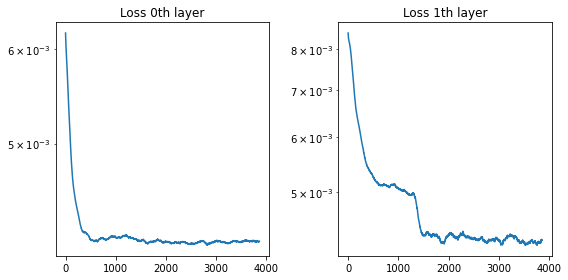

In [148]:
plot_losses(losses, offset=40)

In [ ]:
for k in range(50):
    Q_models, new_losses, val_losses, D = learning_algo(data, val_dataset,nb_layers=2, max_iter=2000,
                                                    epsilon = 0.1, 
                                                    validation = False, include_early_stopping = False, 
                                                    optimisers=opti_list,
                                                    init_models=False, Q_models=Q_models,
                                                    init_D=False, D=D)
    losses = np.concatenate([losses, new_losses], axis = 0)

 40%|████      | 800/2000 [00:14<00:20, 57.67it/s]

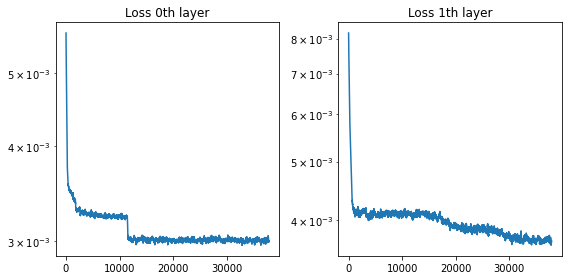

In [139]:
plot_losses(losses, offset=40)

In [140]:
for k in range(5):
    Q_models, new_losses, val_losses, D = learning_algo(data, val_dataset,nb_layers=2, max_iter=2000,
                                                    epsilon = 0.1, 
                                                    validation = False, include_early_stopping = False, 
                                                    optimisers=opti_list,
                                                    init_models=False, Q_models=Q_models,
                                                    init_D=False, D=D)
    losses = np.concatenate([losses, new_losses], axis = 0)

100%|██████████| 2000/2000 [01:10<00:00, 28.41it/s]


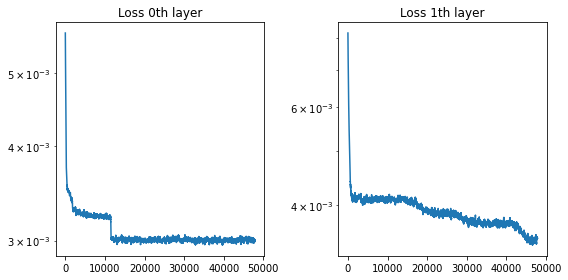

In [141]:
plot_losses(losses, offset=40)

In [74]:
Q_models, losses, val_losses, D = learning_algo(data, val_dataset,nb_layers=2, max_iter=2000,
                                                epsilon = 1, 
                                                optimisers=opti_list,
                                                validation = False, include_early_stopping = False, 
                                                init_models=False, Q_models=Q_models,
                                                init_D=True)

100%|██████████| 2000/2000 [01:03<00:00, 31.32it/s]


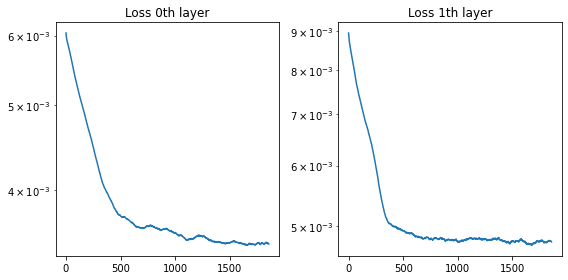

In [75]:
plot_losses(losses, offset=40)

In [149]:
x1, x2, r = peak_one(val_dataset)
tools.ohe_to_hand(x1).pprint()
print()
tools.ohe_to_hand(x2).pprint()
r

♠ A76
♥ J984
♦ A8543
♣ 8

♠ KT4
♥ Q7
♦ KQ92
♣ T973


array([0.84, 0.72, 1.  , 0.76, 0.76, 0.84, 0.68, 1.  , 0.72, 0.72, 0.76,
       0.64, 1.  , 0.68, 0.68, 0.72, 0.6 , 0.8 , 0.64, 0.64, 0.68, 0.56,
       0.76, 0.6 , 0.6 , 0.64, 0.52, 0.72, 0.56, 0.56, 0.6 , 0.52, 0.68,
       0.56, 0.56, 0.56])

In [150]:
Q_models[0](torch.tensor(x1, dtype = torch.float32))

tensor([1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 0.,
        0., 1., 1., 1., 0., 1., 0., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1.],
       grad_fn=<SigmoidBackward0>)

In [151]:
bids = np.zeros(36)
bids[1] = 1
Q_models[1](torch.tensor(np.concatenate([x1,bids]), dtype = torch.float32))

tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1.],
       grad_fn=<SigmoidBackward0>)

In [152]:
perform_bids(x1, x2, np.zeros(36), Q_models, 2)

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0.])

In [95]:
for k in range(500):
    Q_models, new_losses, val_losses, D = learning_algo(data, val_dataset,nb_layers=2, max_iter=2000,
                                                    epsilon = 0.1, 
                                                    validation = False, include_early_stopping = False, 
                                                    optimisers=opti_list,
                                                    init_models=False, Q_models=Q_models,
                                                    init_D=False, D=D)
    losses = np.concatenate([losses, new_losses], axis = 0)

 24%|██▍       | 475/2000 [00:17<00:55, 27.66it/s]


KeyboardInterrupt: 

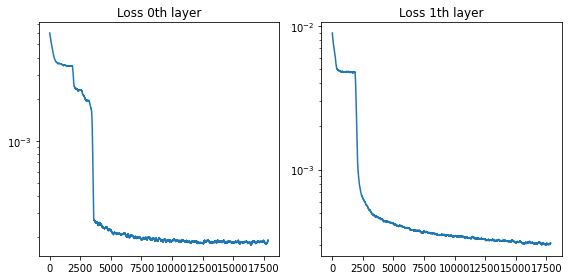

In [96]:
plot_losses(losses, offset=40)

In [106]:
opti_list = [torch.optim.AdamW(model.parameters(), 
                                 lr = 0.0001,
                                 betas = (0.9, 0.999),
                                 weight_decay=0.01) for model in Q_models]
for k in range(500):
    Q_models, new_losses, val_losses, D = learning_algo(data, val_dataset,nb_layers=2, max_iter=2000,
                                                    epsilon = 0.1, 
                                                    validation = False, include_early_stopping = False, 
                                                    optimisers=opti_list,
                                                    init_models=False, Q_models=Q_models,
                                                    init_D=False, D=D)
    losses = np.concatenate([losses, new_losses], axis = 0)

  3%|▎         | 62/2000 [00:02<01:12, 26.74it/s]


KeyboardInterrupt: 

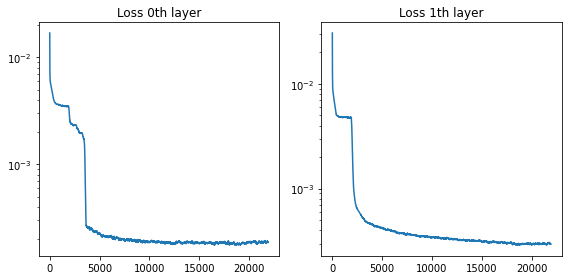

In [108]:
plot_losses(losses, offset=0)

In [115]:
opti_list = [torch.optim.AdamW(model.parameters(), 
                                 lr = 0.001,
                                 betas = (0.9, 0.999),
                                 weight_decay=0.01) for model in Q_models]
for k in range(500):
    Q_models, new_losses, val_losses, D = learning_algo(data, val_dataset,nb_layers=2, max_iter=2000,
                                                    epsilon = 0.1, 
                                                    validation = False, include_early_stopping = False, 
                                                    optimisers=opti_list,
                                                    init_models=False, Q_models=Q_models,
                                                    init_D=False, D=D)
    losses = np.concatenate([losses, new_losses], axis = 0)

  5%|▌         | 109/2000 [00:04<01:21, 23.31it/s]


KeyboardInterrupt: 

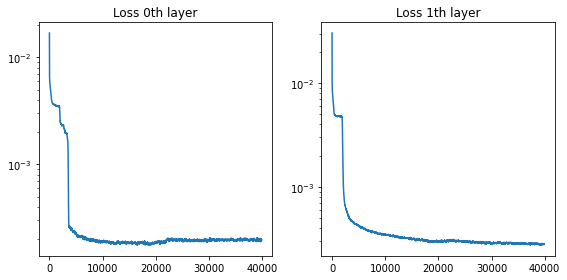

In [116]:
plot_losses(losses, offset=0)

In [119]:
opti_list = [torch.optim.AdamW(model.parameters(), 
                                 lr = 0.001,
                                 betas = (0.9, 0.999),
                                 weight_decay=0.01) for model in Q_models]
for k in range(500):
    Q_models, new_losses, val_losses, D = learning_algo(data, val_dataset,nb_layers=2, max_iter=2000,
                                                    epsilon = 0.01, 
                                                    validation = False, include_early_stopping = False, 
                                                    optimisers=opti_list,
                                                    init_models=False, Q_models=Q_models,
                                                    init_D=False, D=D)
    losses = np.concatenate([losses, new_losses], axis = 0)

  2%|▏         | 41/2000 [00:01<01:25, 22.88it/s]


KeyboardInterrupt: 

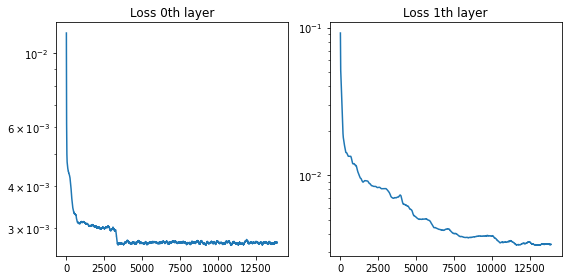

In [120]:
plot_losses(losses, offset=0)

# Test

In [ ]:
test_dataset = pd.concat([pd.read_csv(f"data/slice{k}.csv", index_col = 0) for k in range (12, 14)])
results = assess_models(Q_models, test_dataset)
results*25

c:\Users\Chardin Pierre\OneDrive - CentraleSupelec\Bureau\CS\3a\DL\brige\RL-for-bridge-bidding\learning_tools.py:38: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  state = torch.tensor(hand, dtype=torch.float32) if i == 0 else torch.tensor(
c:\Users\Chardin Pierre\OneDrive - CentraleSupelec\Bureau\CS\3a\DL\brige\RL-for-bridge-bidding\learning_tools.py:59: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return scores[last_action], last_layer


array([15.5       , 16.77827783])